Chelsea Veneziano

Term Project: Comprehensive Exploratory Data Analysis and Regression Analysis of Heart Disease Data

In [37]:
# load library
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('HeartDiseaseTrain-Test.csv')

# Display the first few rows of the DataFrame
print(df.head())

# Display the DataFrame info
df.info()

# Select the relevant columns
variables = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral']

# Display summary statistics of the selected columns
df[variables].describe()


   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                           Two   
1 

,age,resting_blood_pressure,cholestoral
count,1025.000000,1025.000000,1025.00000
mean,54.434146,131.611707,246.00000
std,9.072290,17.516718,51.59251
min,29.000000,94.000000,126.00000
25%,48.000000,120.000000,211.00000
50%,56.000000,130.000000,240.00000
75%,61.000000,140.000000,275.00000
max,77.000000,200.000000,564.00000


Variable Decription: 
1. age: Age of the patient.
2. sex: Sex of the patient (Male or Female).
3. chest_pain_type: Type of chest pain (Typical angina, Atypical angina, Non-anginal pain, Asymptomatic).
4. resting_blood_pressure: Resting blood pressure (in mm Hg on admission to the hospital).
5. cholestoral: Serum cholesterol in mg/dl.

Histograms and Descriptive Statistics

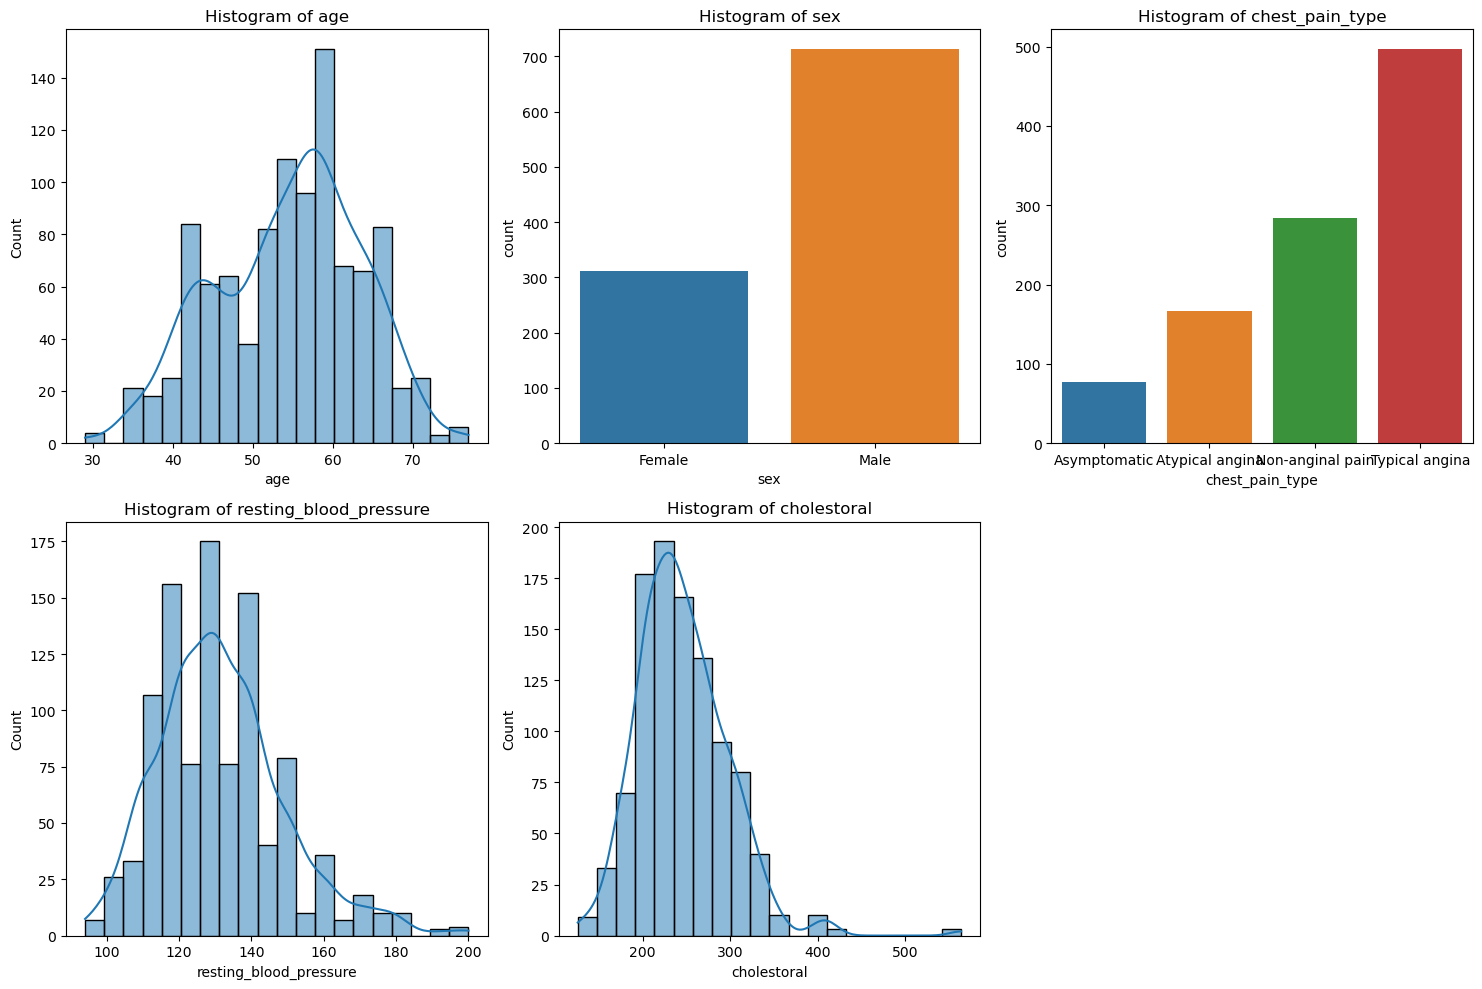

In [38]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress specific FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning, message="use_inf_as_na option is deprecated")
warnings.filterwarnings("ignore", category=FutureWarning, message="The default of observed=False is deprecated")

# Load the CSV file into a DataFrame
df = pd.read_csv('HeartDiseaseTrain-Test.csv')

# Ensure the correct data types
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['resting_blood_pressure'] = pd.to_numeric(df['resting_blood_pressure'], errors='coerce')
df['cholestoral'] = pd.to_numeric(df['cholestoral'], errors='coerce')
df['sex'] = df['sex'].astype('category')
df['chest_pain_type'] = df['chest_pain_type'].astype('category')

# Select the relevant columns
variables = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral']

# Data Cleaning
# Replace infinite values with NaNs
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaNs
df.dropna(subset=variables, inplace=True)

# Plot histograms
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

for i, var in enumerate(variables):
    if df[var].dtype.name == 'category':
        sns.countplot(x=var, data=df, ax=axs[i])
    else:
        sns.histplot(df[var], bins=20, kde=True, ax=axs[i])
    axs[i].set_title(f'Histogram of {var}')

# Remove the last (empty) subplot
fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()


Explanations:

Histogram of Age: The histogram of age shows a relatively normal distribution with a peak around the age of 55. Most patients fall within the age range of 40 to 70. The distribution indicates that the dataset primarily consists of middle-aged to older adults, which is typical for heart disease studies.

Histogram of Sex: The histogram shows that there are more male patients than female patients in the dataset. This could reflect the higher incidence of heart disease in males compared to females or sampling bias.

Histogram of Chest Pain Type: The histogram of chest pain type shows the distribution of different types of chest pain among the patients.
Typical angina is the most common type, followed by non-anginal pain and atypical angina. Asymptomatic cases are the least common.
This distribution helps understand the prevalence of different chest pain types in the dataset.

Histogram of Resting Blood Pressure: The histogram of resting blood pressure shows a slightly skewed distribution with a peak around 130-140 mm Hg. There are a few outliers with very high resting blood pressure, indicating potential cases of severe hypertension.
This distribution helps understand the range and common values of resting blood pressure in the patient population.

Histogram of Cholesterol: The histogram of cholesterol shows a distribution with a peak around 200-250 mg/dl. There are some outliers with extremely high cholesterol levels, which might indicate severe hypercholesterolemia. This distribution helps understand the cholesterol levels in the patient population.

PMF Comparison: Compare two scenarios using the PMF of chest_pain_type

In [39]:
# Calculate PMF for chest pain type
pmf_cp = df['chest_pain_type'].value_counts(normalize=True)
print("\nPMF for chest pain type:\n", pmf_cp)

# Compare scenarios: Typical angina (chest_pain_type='Typical angina') vs. all other types
typical_angina = df[df['chest_pain_type'] == 'Typical angina']['chest_pain_type']
other_angina = df[df['chest_pain_type'] != 'Typical angina']['chest_pain_type']

pmf_typical_angina = typical_angina.value_counts(normalize=True)
pmf_other_angina = other_angina.value_counts(normalize=True)

print("\nPMF for typical angina:\n", pmf_typical_angina)
print("\nPMF for other types of angina:\n", pmf_other_angina)



PMF for chest pain type:
 chest_pain_type
Typical angina      0.484878
Non-anginal pain    0.277073
Atypical angina     0.162927
Asymptomatic        0.075122
Name: proportion, dtype: float64

PMF for typical angina:
 chest_pain_type
Typical angina      1.0
Asymptomatic        0.0
Atypical angina     0.0
Non-anginal pain    0.0
Name: proportion, dtype: float64

PMF for other types of angina:
 chest_pain_type
Non-anginal pain    0.537879
Atypical angina     0.316288
Asymptomatic        0.145833
Typical angina      0.000000
Name: proportion, dtype: float64


Explanations:
PMF for chest pain type: PMF for chest pain type indicates that typical angina is the most common type of chest pain among the patients, with a probability of approximately 48.49%. Non-anginal pain and atypical angina have lower probabilities of approximately 27.71% and 16.29%. Asymptomatic cases are the least common, with a probability of about 7.51%.

PMF for typical angina: The PMF for typical angina shows that, in the subset of data filtered for typical angina, 100% of the cases fall under the category of typical angina, with no instances of other types of chest pain.

PMF for other types of angina: The PMF for other types of angina, excluding typical angina, indicates that non-anginal pain is the most prevalent, comprising approximately 53.79% of the cases. Atypical angina and asymptomatic cases follow with probabilities of approximately 31.63% and 14.58%. There are no instances of typical angina in this subset.



CDF Analysis: Create a CDF for the age variable

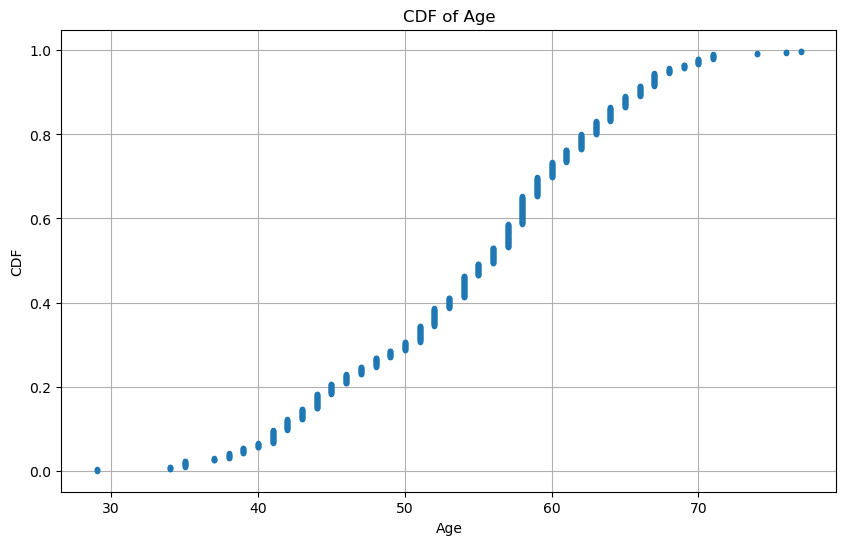

In [40]:

# Compute CDF
data = df['age']
data_sorted = np.sort(data)
cdf = np.arange(len(data_sorted)) / float(len(data_sorted))

plt.figure(figsize=(10, 6))
plt.plot(data_sorted, cdf, marker='.', linestyle='none')
plt.xlabel('Age')
plt.ylabel('CDF')
plt.title('CDF of Age')
plt.grid(True)
plt.show()


Explantaion: By observing the CDF, we can determine the age distribution of the patients in the dataset. For instance, we can infer the median age (the age below which 50% of the patients fall) by finding the point where the CDF equals 0.5.

Analytical Distribution: Fit a normal distribution to cholestoral and plot

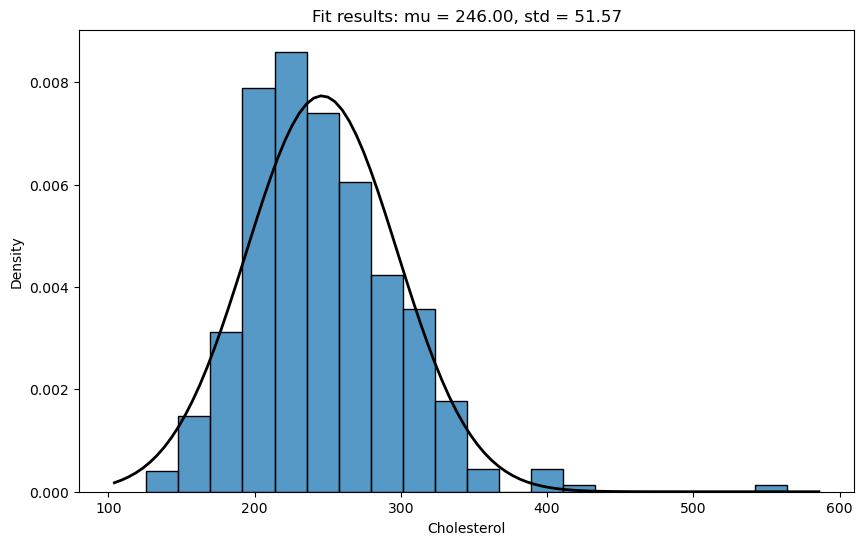

In [41]:
from scipy.stats import norm

# Fit a normal distribution
mu, std = norm.fit(df['cholestoral'])

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['cholestoral'], bins=20, kde=False, stat="density")

# Plot the PDF
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Fit results: mu = %.2f, std = %.2f' % (mu, std))
plt.xlabel('Cholesterol')
plt.ylabel('Density')
plt.show()


Explanation: The graph above represents the distribution of the cholestoral variable fitted with a normal distribution curve. The histogram shows the frequency distribution of cholesterol levels among the patients, while the overlaid line represents the normal distribution fit based on the data.

Scatter Plots and Correlation Analysis: Create scatter plots and analyze correlation

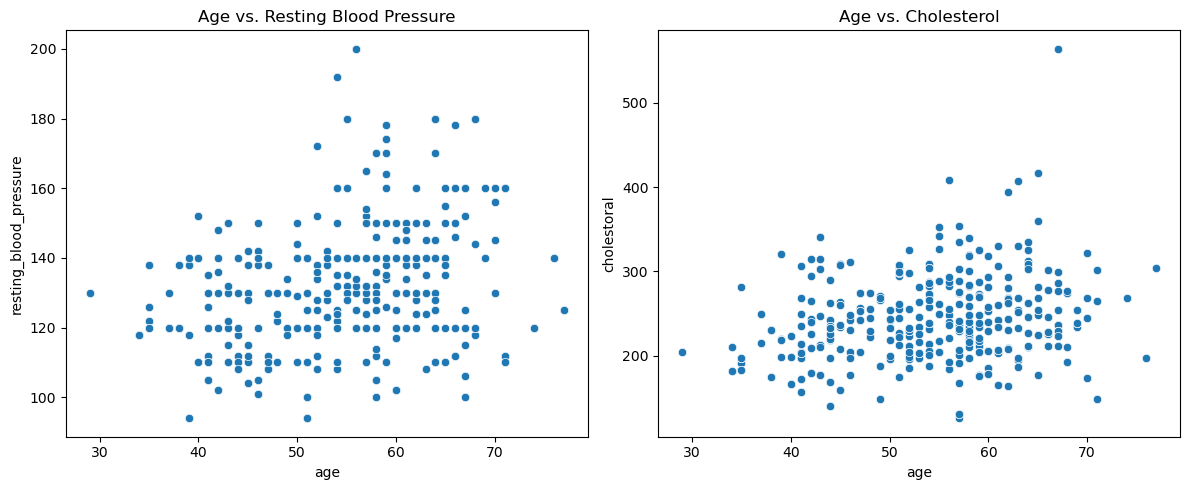

Correlation matrix:
                              age       sex  chest_pain_type  \
age                     1.000000 -0.103240         0.107819   
sex                    -0.103240  1.000000         0.007902   
chest_pain_type         0.107819  0.007902         1.000000   
resting_blood_pressure  0.271121 -0.078974        -0.032418   
cholestoral             0.219823 -0.198258         0.070620   

                        resting_blood_pressure  cholestoral  
age                                   0.271121     0.219823  
sex                                  -0.078974    -0.198258  
chest_pain_type                      -0.032418     0.070620  
resting_blood_pressure                1.000000     0.127977  
cholestoral                           0.127977     1.000000  


In [42]:
# Convert categorical variables to numeric
df['sex'] = df['sex'].astype('category').cat.codes  # Convert to numeric
df['chest_pain_type'] = df['chest_pain_type'].astype('category').cat.codes  # Convert to numeric

# Select the relevant columns
variables = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral']

# Plot scatter plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='age', y='resting_blood_pressure', data=df)
plt.title('Age vs. Resting Blood Pressure')

plt.subplot(1, 2, 2)
sns.scatterplot(x='age', y='cholestoral', data=df)
plt.title('Age vs. Cholesterol')

plt.tight_layout()
plt.show()

# Correlation analysis
correlation_matrix = df[variables].corr()
print("Correlation matrix:\n", correlation_matrix)


Explanations: 
Age vs. Resting Blood Pressure: There is no clear linear trend visible in the scatter plot, suggesting a weak or no correlation between age and resting blood pressure.

Age vs. Cholesterol: Similar to the first plot, there is no clear linear trend visible, suggesting a weak or no correlation between age and cholesterol levels.

Hypothesis testing: Conduct a hypothesis test on one of the variables

In [43]:
from scipy.stats import ttest_ind

# Ensure there are no missing values in the sex and resting_blood_pressure columns
df_clean = df.dropna(subset=['sex', 'resting_blood_pressure'])

# Separate the resting blood pressure values for males and females
male_bp = df_clean[df_clean['sex'] == 1]['resting_blood_pressure']
female_bp = df_clean[df_clean['sex'] == 0]['resting_blood_pressure']

# Perform the t-test
t_stat, p_val = ttest_ind(male_bp, female_bp)

print(f'T-test result: t-statistic = {t_stat}, p-value = {p_val}')


T-test result: t-statistic = -2.533840303766843, p-value = 0.011430321504680553


Explanation: Since the p-value is less than 0.05, we reject the null hypothesis that there is no difference in resting blood pressure between males and females. This suggests that there is a statistically significant difference in resting blood pressure between the two groups, with males having a slightly lower mean resting blood pressure compared to females.

Regression analysis: Perform a regression analysis

In [44]:
import statsmodels.api as sm

# Dependent variable: resting_blood_pressure
y = df['resting_blood_pressure']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Display the model summary
print(model.summary())


                              OLS Regression Results                              
Dep. Variable:     resting_blood_pressure   R-squared:                       0.080
Model:                                OLS   Adj. R-squared:                  0.077
Method:                     Least Squares   F-statistic:                     29.58
Date:                    Tue, 28 May 2024   Prob (F-statistic):           2.44e-18
Time:                            17:34:40   Log-Likelihood:                -4345.9
No. Observations:                    1025   AIC:                             8700.
Df Residuals:                        1021   BIC:                             8720.
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const     

Explanation: The regression analysis reveals that age and cholesterol are significant predictors of resting blood pressure, with age having a more substantial effect. The model, however, explains only a small portion of the variability in resting blood pressure, indicating that other factors not included in the model may play a more significant role.

Statistical/Hypothetical Question

The primary question driving this analysis was: "Do age, sex, and cholesterol levels significantly affect resting blood pressure in heart disease patients?" This question aims to identify whether these factors are significant predictors of resting blood pressure, which is a crucial metric in cardiovascular health. The Exploratory Data Analysis provided several insights:
Age Distribution: The patient population is predominantly middle-aged to older adults, with most patients between 40 and 70 years old.
Sex Distribution: There are more male patients than female patients, reflecting a potential higher incidence of heart disease in males or sampling bias.
Chest Pain Types: Typical angina is the most common chest pain type, followed by non-anginal pain, atypical angina, and asymptomatic cases.
Resting Blood Pressure: Most patients have resting blood pressure in the range of 130-140 mm Hg, with some outliers indicating severe hypertension.
Cholesterol Levels: Cholesterol levels mostly range from 200 to 250 mg/dl, with some outliers indicating severe hypercholesterolemia.
The scatter plots and correlation matrix revealed weak correlations between age, cholesterol, and resting blood pressure. The hypothesis test showed a statistically significant difference in resting blood pressure between males and females, with males having slightly lower mean resting blood pressure.

What I Feel Was Missed During the Analysis?
The analysis did not account for other potential predictors of resting blood pressure, such as smoking status, physical activity level, diet, family history of hypertension, and medication use. These factors could have provided a more comprehensive understanding of the determinants of resting blood pressure.

Were There Any Variables You Felt Could Have Helped in the Analysis?
Yes, several additional variables could have been beneficial:
Smoking Status: Smoking is a known risk factor for hypertension and cardiovascular disease.
Physical Activity: Regular physical activity can influence blood pressure levels.
Diet: Dietary habits, especially salt intake, significantly affect blood pressure.
Medication Use: Use of antihypertensive medications could directly impact resting blood pressure readings.
Family History: Genetic predisposition plays a role in the likelihood of developing hypertension.

Were There Any Assumptions Made You Felt Were Incorrect?
One key assumption was that the relationships between the predictors and resting blood pressure were linear, which may not fully capture the complexities of these relationships. Additionally, the assumption that the dataset was representative of the broader population might not hold, given potential sampling biases.

What Challenges Did You Face, What Did You Not Fully Understand?
A challenge for me was ensuring the accuracy of the data preprocessing steps, particularly handling missing values and converting categorical variables to numerical codes for analysis. Understanding the nuances of statistical tests and interpreting the results correctly, especially in the context of medical data, required careful consideration and validation.

This analysis provided valuable insights into the relationships between age, sex, cholesterol levels, and resting blood pressure in heart disease patients. However, incorporating additional relevant variables and considering non-linear relationships could improve the model's explanatory power and provide a more comprehensive understanding of the factors influencing resting blood pressure. Despite the challenges, the findings contribute to the broader understanding of cardiovascular health and highlight areas for further research.